In [6]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath('src'))

from src.config import SIM_CONFIG
from src.users import generate_users
from src.sessions import generate_sessions
from src.events import generate_events
from src.orders import generate_orders
from src.order_items import generate_order_items

rng = np.random.default_rng(seed=42)
print("modules loaded successfully.")

modules loaded successfully.


In [7]:
test_users_df = generate_users(total_users=1000000, rng=rng)
display(test_users_df.head())

Generating 1000000 users
users table generated!


,user_id,account_created_at,city,region,user_tenure_days,latent_income_score,latent_digital_literacy,latent_trust_in_platform
0,4d080a488dab4b989e5c2dfacf952f1c,2024-11-28 04:21:20,davao_del_norte,region_xi,32,0.334835,0.039387,0.498106
1,3d2f95f3ec414a70b59709c4432cd070,2024-03-23 15:20:48,cebu,region_vii,282,0.078654,0.700104,0.049789
2,86ae29972e74401aa4f54a619ba92f48,2024-05-06 06:09:19,siquijor,nir,238,0.836328,0.424339,0.271859
3,0c3e0ea51d49412a9c233d6bebbd1745,2024-07-23 22:47:29,makati,ncr,160,0.999611,0.141295,0.104224
4,0e19f3ccea8042368dc5f4546cd31c16,2024-07-25 08:38:11,cavite,region_iv-a,158,1.000962,0.595593,0.166513


In [8]:
test_sessions_df = generate_sessions(df_users=test_users_df, rng=rng)
display(test_sessions_df.head())

Generating 1900888 sessions
sessions table generated!


,session_id,user_id,session_number,acq_channel,utm_source,utm_medium,utm_campaign,session_start_time,session_end_time,session_duration_seconds,device_operating_system,device_operating_system_version,device_group
0,22108781a48c4ade826870e37573a442,4d080a488dab4b989e5c2dfacf952f1c,1,tiktok,tiktok,cpc,flash_sale,2024-12-15 16:04:19,2024-12-15 16:08:17,238,ios,17.3,mobile
1,29941b5e3fac4cc9b2e77cd71cf18629,3d2f95f3ec414a70b59709c4432cd070,1,meta,facebook,cpc,spring_sale,2024-03-23 12:02:03,2024-03-23 12:02:24,21,android,14,mobile
2,e59a152047bb4edea09bfc1f631f4cd2,86ae29972e74401aa4f54a619ba92f48,1,organic,bing,organic,(not_set),2024-11-12 01:59:03,2024-11-12 02:07:05,482,android,14,mobile
3,c7a2ddb6458046bda63ca8f4210b0330,0c3e0ea51d49412a9c233d6bebbd1745,1,tiktok,tiktok,influencer,summer_vibes,2024-07-30 13:10:03,2024-07-30 13:11:54,111,ios,16.5,mobile
4,15a309438b7840079a2e8b72b3e1c5ab,0c3e0ea51d49412a9c233d6bebbd1745,2,meta,ig,social,retargeting,2024-07-23 15:04:12,2024-07-23 15:05:32,80,windows,11,desktop


In [9]:
test_events_df = generate_events(df_sessions=test_sessions_df, df_users=test_users_df, rng=rng, n_workers=1)
display(test_events_df.head())

Generating events for 1900888 sessions


,event_id,session_id,event_timestamp,event_name,viewed_category,android_error
0,4910a14a-d732-4a4e-88c2-b23f783e881f,22108781a48c4ade826870e37573a442,2024-12-15 16:04:19,view_item,baby_and_kids,NaN
1,c5aa10a8-a588-4d77-82dd-7a75fbccff88,29941b5e3fac4cc9b2e77cd71cf18629,2024-03-23 12:02:03,view_item,beauty_and_personal_care,NaN
2,df28aa9c-5411-4bd2-b804-7a35010cc153,29941b5e3fac4cc9b2e77cd71cf18629,2024-03-23 12:02:17,add_to_cart,beauty_and_personal_care,NaN
3,114c5e95-2c03-4e47-9b1a-38cf1a15813a,e59a152047bb4edea09bfc1f631f4cd2,2024-11-12 01:59:03,view_item,food_and_beverage,NaN
4,787c7483-3430-4d11-8fdf-d2a1c0cc6391,c7a2ddb6458046bda63ca8f4210b0330,2024-07-30 13:10:03,view_item,consumer_electronics,NaN


In [10]:
test_orders_df = generate_orders(df_events=test_events_df, df_sessions=test_sessions_df, rng=rng)
display(test_orders_df.head())

Generating 59236 orders for purchases events
orders table generated!


,order_id,session_id,user_id,order_timestamp,payment_type
0,492fc0778eae4d41b3006d1dc2f3b28d,cb490a25e94d4132853d36e5b6879c3a,69d48c0b5ed84c2dae9dc4c76ff5a6ad,2024-02-15 09:11:37,cod
1,fdc87b563fc948618daa7beb5635019f,8aa296931aee456d9eab11986c8d07d7,c2a59bd4631a4c0ba2830275e178b4bf,2024-05-14 23:15:17,digital_wallet
2,6bb919b3eb52496dab579b1c6c4ceda6,80706b05617142abbc9b923f331c613a,5adf194dc2c5455f9a88a76d3b9c2c7c,2024-07-19 23:18:28,digital_wallet
3,e6b2c0f5681640ef8c6f41ec1a01791c,0abebf75979d462d9eea4d4b873da891,ec905c3bed5942dcbd56b1c6bd32e64f,2024-09-06 12:37:28,bank_transfer
4,8a81cc95df8b443e8eccb073cd9184bd,8707795cfc6f40509d1e396edc571a09,b49c766a4e5b40b28309182414a4d400,2024-01-03 21:21:55,digital_wallet


In [11]:
test_order_items_df = generate_order_items(df_orders=test_orders_df, df_users=test_users_df, rng=rng)
display(test_order_items_df.head())

Generating order items for 59236 orders
order items table generated!


,order_item_id,order_id,item_category,base_item_price,final_item_price,quantity,discount_percentage
0,8fb7d1e0f059434a8618011b25099332,492fc0778eae4d41b3006d1dc2f3b28d,food_and_beverage,163.99,163.99,1,0.0
1,799edb54faff46d4b08d670c53bae8c4,492fc0778eae4d41b3006d1dc2f3b28d,beauty_and_personal_care,274.99,274.99,2,0.0
2,97d0dde629d941318e79b2fb3dbae5e1,fdc87b563fc948618daa7beb5635019f,food_and_beverage,154.99,154.99,1,0.0
3,2bda9c0f112e40a8a5b97707bda92f5b,6bb919b3eb52496dab579b1c6c4ceda6,lifestyle_and_fitness,500.99,450.89,2,0.1
4,3ab1ffce3b57401182d7858232d7d93c,6bb919b3eb52496dab579b1c6c4ceda6,beauty_and_personal_care,256.99,256.99,1,0.0


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def internal_validation(df_users, df_sessions, df_events, df_orders, df_order_items):
    print("=== BEGINNING INTERNAL DAG VALIDATION ===")

    # 1. Checking referential integrity
    purchase_sessions = df_events[df_events['event_name'] == 'purchase']['session_id'].unique()
    orphaned_orders = df_orders[~df_orders['session_id'].isin(purchase_sessions)]
    
    print("\n1. Referential Integrity:")
    if orphaned_orders.empty:
        print("   ✅ PASS: All orders have a corresponding 'purchase' event.")
    else:
        print(f"   ❌ FAIL: Found {len(orphaned_orders)} orders without a purchase event!")
        
    # 2. Funnel baseline calibration (markov chain)
    print("\n2. Markov Chain Funnel Calibration:")
    event_counts = df_events['event_name'].value_counts()
    views = event_counts.get('view_item', 1)
    purchases = event_counts.get('purchase', 0)
    conversion_rate = (purchases / views) * 100
    print(f"   Total Views: {views:,}")
    print(f"   Total Purchases: {purchases:,}")
    print(f"   View-to-Purchase Conversion Rate: {conversion_rate:.2f}% (Target: ~2.25%)")
    
    if 1.5 <= conversion_rate <= 3.0:
        print("   ✅ PASS: Conversion rate is within realistic bounds.")
    else:
        print("   ⚠️ WARNING: Conversion rate is drifting from target.")

    # 3. Behavioral Decay Assertion (Exponential)
    print(f"\n3. Temporal Decay (Digital Literacy vs. Session Duration):")
    # Merge sessions with users to access the exact column name: latent_digital_literacy
    df_sess_user = df_sessions.merge(df_users[['user_id', 'latent_digital_literacy']], on='user_id')
    
    try:
        # Calculate the deciles and the trend
        df_sess_user['literacy_decile'] = pd.qcut(df_sess_user['latent_digital_literacy'].rank(method='first'), q=10, labels=False)
        decay_trend = df_sess_user.groupby('literacy_decile')['session_duration_seconds'].mean()
        
        # Extract the exact mean durations for the lowest (0) and highest (9) deciles
        lowest_literacy_mean = decay_trend.iloc[0]
        highest_literacy_mean = decay_trend.iloc[-1]
        
        is_decreasing = lowest_literacy_mean > highest_literacy_mean
        if is_decreasing:
            print("✅ PASS: Higher digital literacy results in lower mean session duration.")
            print(f"   -> Bottom 10% Literacy (Novice): Avg {lowest_literacy_mean:.2f} seconds per session")
            print(f"   -> Top 10% Literacy (Expert): Avg {highest_literacy_mean:.2f} seconds per session")
            print(f"   -> Difference: Experts navigate {lowest_literacy_mean - highest_literacy_mean:.2f} seconds faster.")
        else:
            print("❌ FAIL: Session duration does not correlate correctly with digital literacy.")
            print(f"   -> Bottom 10% Mean: {lowest_literacy_mean:.2f}s | Top 10% Mean: {highest_literacy_mean:.2f}s")
    except Exception as e:
        print(f"⚠️ Could not calculate deciles. Error: {e}")
        
    # 4. Financial Distribution Assertion (Log-Normal)
    print("\n4. Financial Shift (Latent Income vs. Base Price):")
    df_fin = df_order_items.merge(df_orders[['order_id', 'user_id']], on='order_id')
    df_fin = df_fin.merge(df_users[['user_id', 'latent_income_score']], on='user_id')
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_fin, x='latent_income_score', y='base_item_price', alpha=0.3)
    plt.title("Internal Validation: Latent Income vs Item Price")
    plt.xlabel("Latent Income Score")
    plt.ylabel("Base Item Price (₱)")
    plt.show()

=== BEGINNING INTERNAL DAG VALIDATION ===

1. Referential Integrity:
   ✅ PASS: All orders have a corresponding 'purchase' event.

2. Markov Chain Funnel Calibration:
   Total Views: 2,579,136
   Total Purchases: 59,236
   View-to-Purchase Conversion Rate: 2.30% (Target: ~2.25%)
   ✅ PASS: Conversion rate is within realistic bounds.

3. Temporal Decay (Digital Literacy vs. Session Duration):
✅ PASS: Higher digital literacy results in lower mean session duration.
   -> Bottom 10% Literacy (Novice): Avg 320.96 seconds per session
   -> Top 10% Literacy (Expert): Avg 208.33 seconds per session
   -> Difference: Experts navigate 112.63 seconds faster.

4. Financial Shift (Latent Income vs. Base Price):


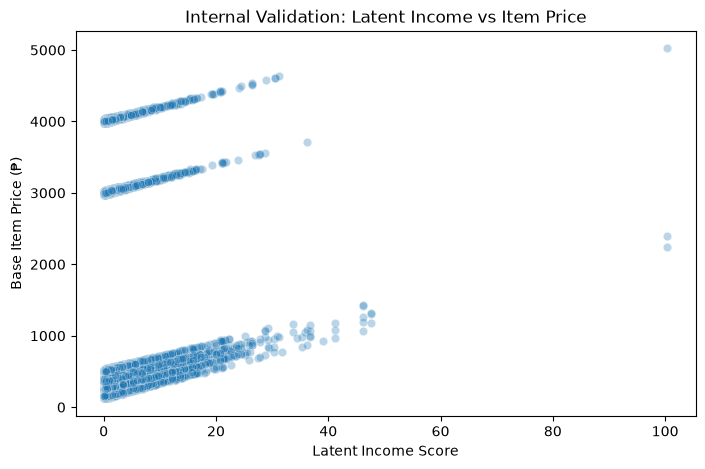

In [13]:
# Run the internal DAG and math validation
internal_validation(test_users_df, test_sessions_df, test_events_df, test_orders_df, test_order_items_df)